In [1]:
import os, numpy as np, polars as pl, tensorflow as tf, sys
from pathlib import Path

repo_root = Path().resolve().parents[3]
sys.path.insert(0, str(repo_root))

from src.preprocessing.preprocessing import processor
from src.models.lstm_transformer import LSTMTransformer
from src.utils.helpers import create_sequences
from src.postprocessing.postprocessing import PostProcessor
from src.models.transformer import TransformerBlock

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [3]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.7 (206.5MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06464100"
	"06917060"
	"06447500"
	"06036650"
	"06061500"
	…
	"06921590"
	"06446700"
	"06892000"
	"06909500"
	"06935755"
]
(4818417, 31)
X_test shape: (338699, 72, 28)
y_test shape: (338699,)


In [ ]:
_tmp = LSTMTransformer()
asymmetric_mse = _tmp._loss()

model = LSTMTransformer.load_model(
    "hybrid_model2.keras",
    custom_objects={
        "asymmetric_mse": asymmetric_mse,}
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 16)         │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 72, 8)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 72, 16)         │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 72, 16)         │         2,504 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,717 (80.93 KB)

 Trainable params: 6,905 (26.97 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,812 (53.96 KB)

In [5]:
model.evaluate(X_test, y_test)

Test loss: 1.5646  |  MAE (scaled): 0.6727


In [6]:
from src.postprocessing.postprocessing import PostProcessor

pp = PostProcessor(
    model=model,
    X_test=X_test,
    y_test=y_test,
    site_ids=test_site_ids,
    target_scaler=pcr.target_scaler,
    feature_names=DYNAMIC_FEATURES + STATIC_FEATURES,
)

10585/10585 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step
Overall test loss: 1.5646  |  MAE (scaled): 0.6727

Site 06036650:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             2029.4 CFS       1945.3 CFS    851.2 CFS


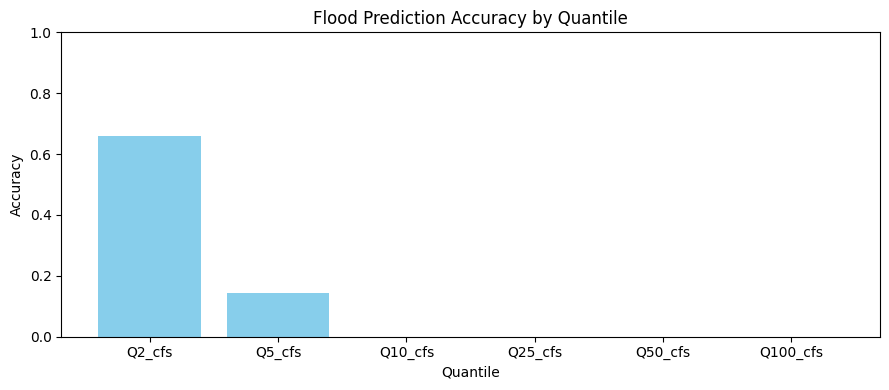


Site 06061500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               54.8 CFS       -594.1 CFS    648.9 CFS


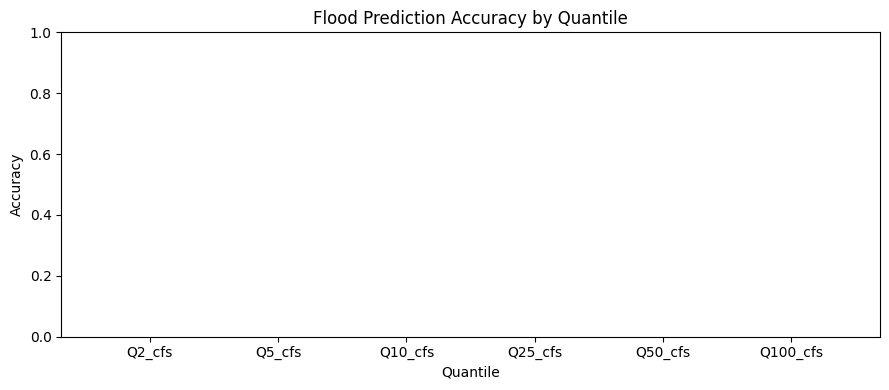


Site 06093200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              202.0 CFS       -447.4 CFS    649.7 CFS


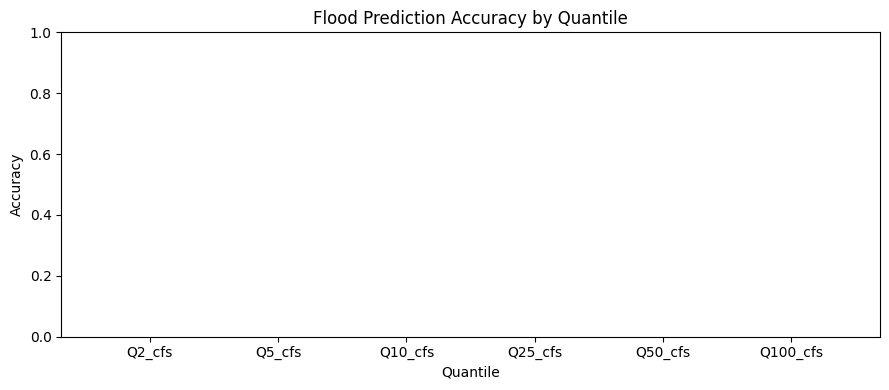


Site 06188000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1434.5 CFS       1316.4 CFS   1159.2 CFS


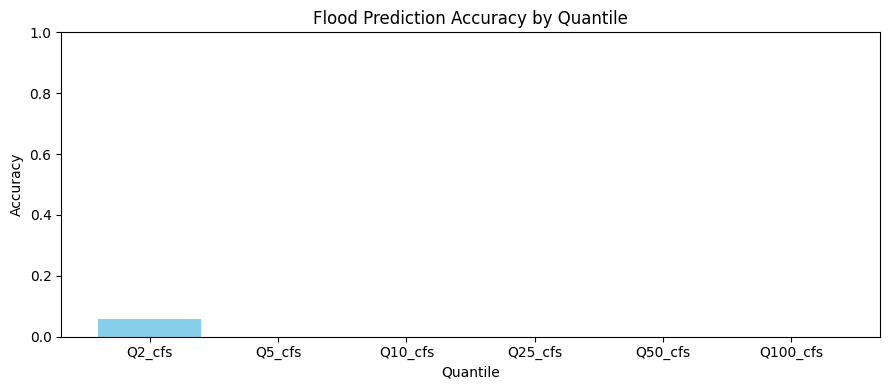


Site 06207500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1143.6 CFS        909.6 CFS    958.1 CFS


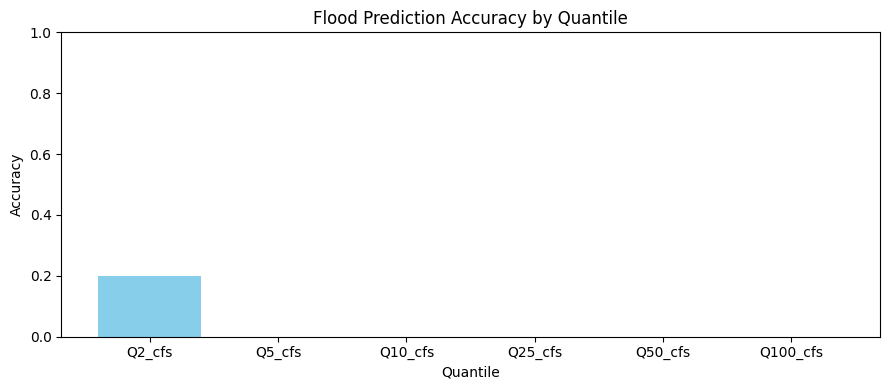


Site 06211000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              104.2 CFS       -548.0 CFS    652.2 CFS


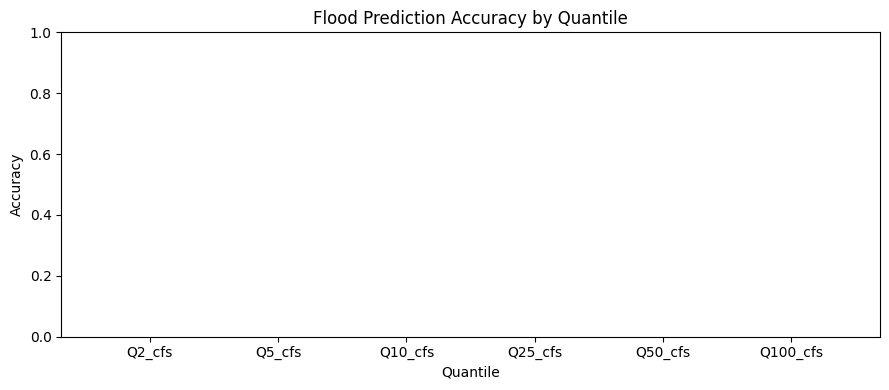


Site 06308500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              539.0 CFS        -73.3 CFS    730.8 CFS


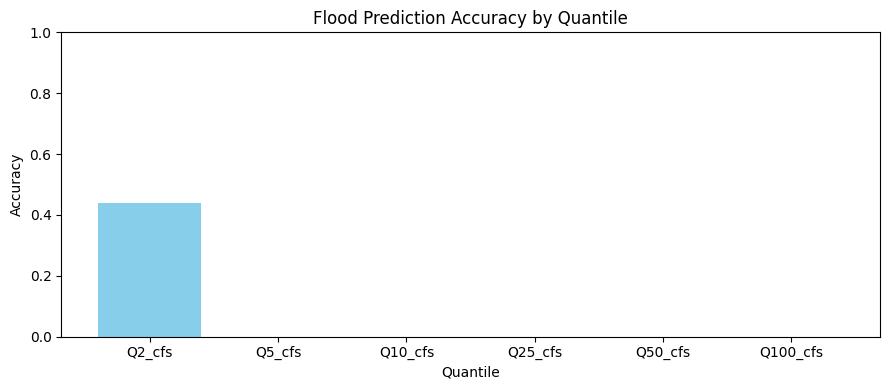


Site 06440200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               23.4 CFS       -638.8 CFS    662.1 CFS


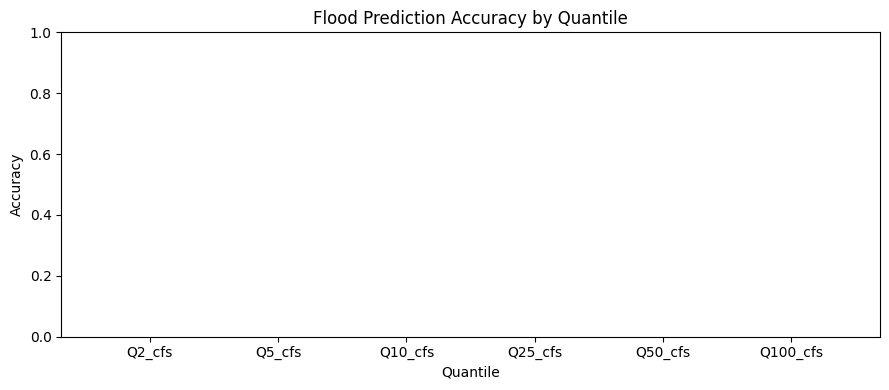


Site 06446700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               27.1 CFS       -649.4 CFS    676.4 CFS


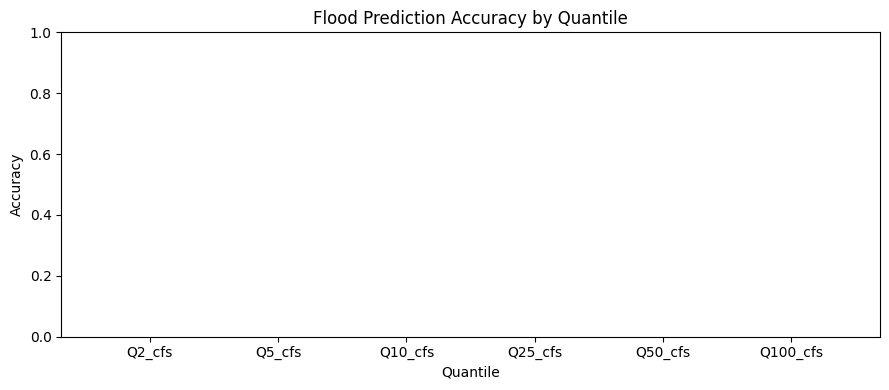


Site 06447500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               36.2 CFS       -644.5 CFS    680.7 CFS


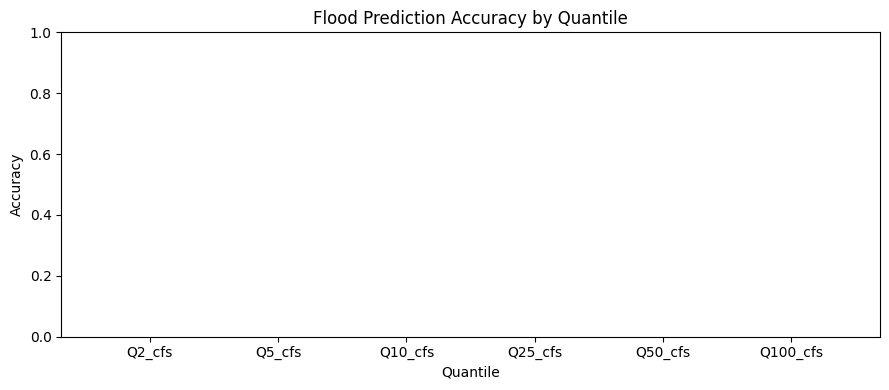


Site 06449000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               34.7 CFS       -647.9 CFS    682.6 CFS


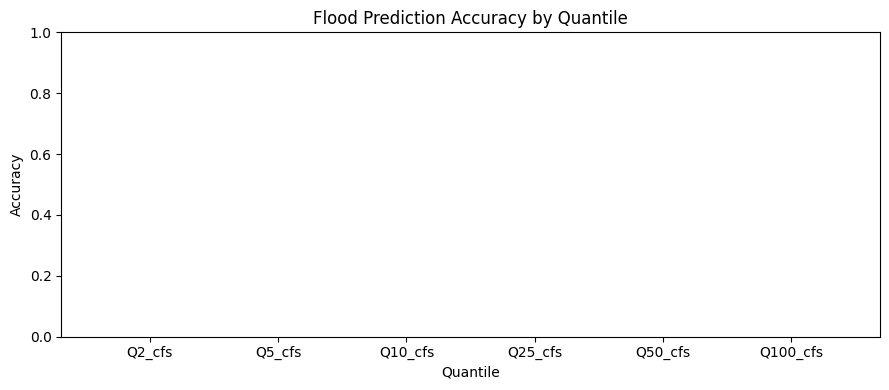


Site 06450500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              243.2 CFS       -440.6 CFS    686.5 CFS


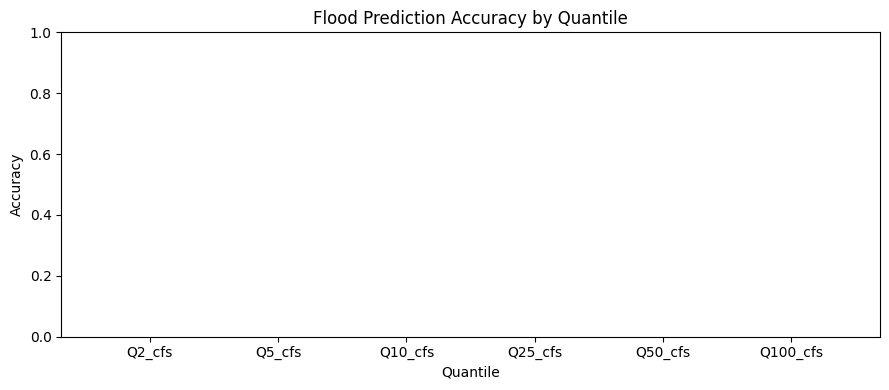


Site 06464100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               66.6 CFS       -631.9 CFS    698.5 CFS


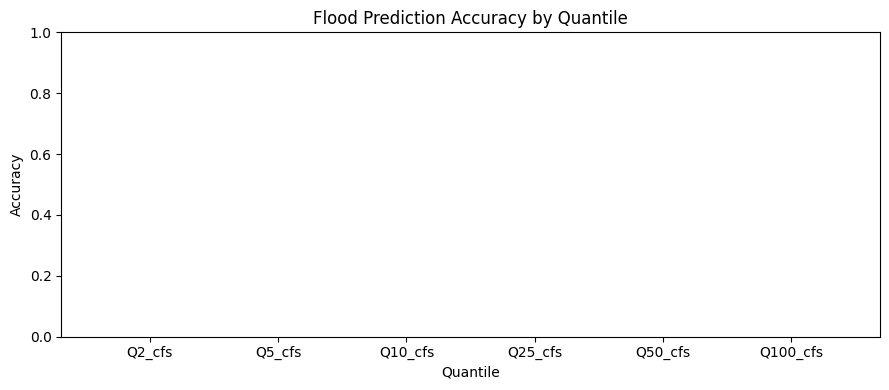


Site 06465700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              179.7 CFS       -508.9 CFS    688.7 CFS


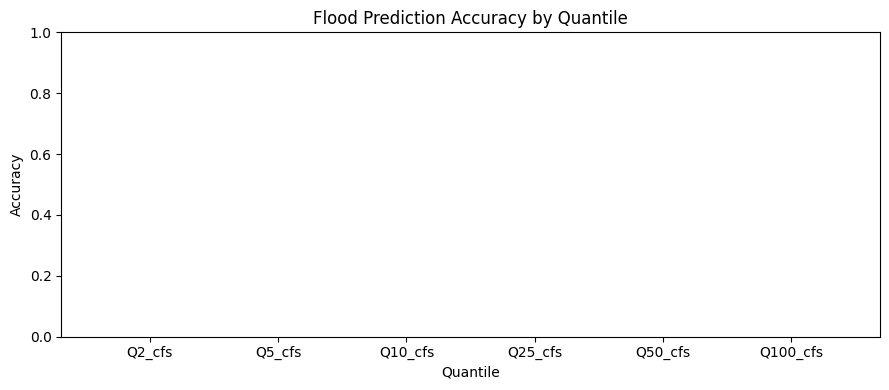


Site 06700000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              200.8 CFS       -525.1 CFS    725.9 CFS


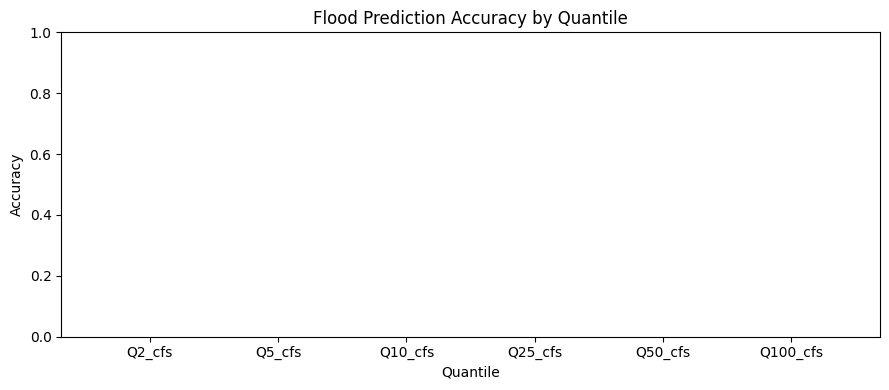


Site 06710385:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               42.7 CFS       -630.3 CFS    673.0 CFS


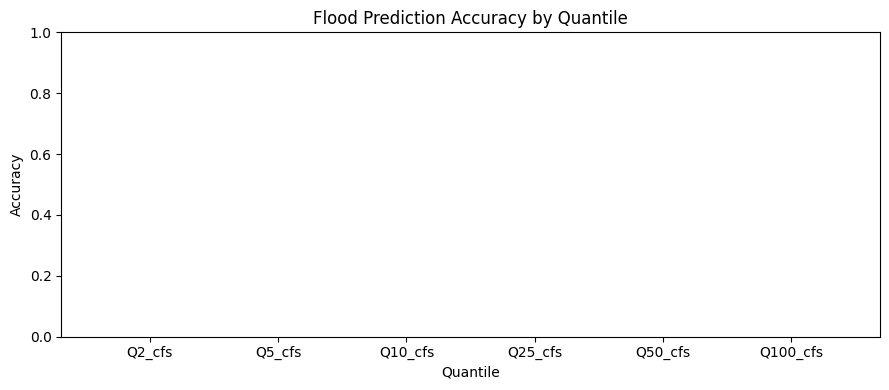


Site 06784000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              235.6 CFS       -467.6 CFS    740.0 CFS


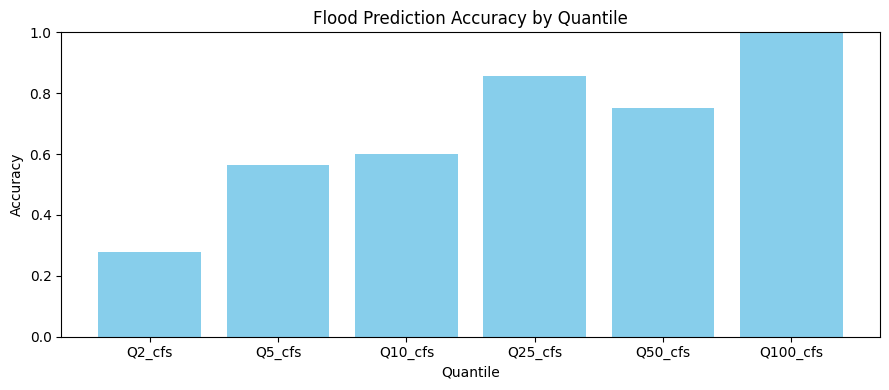


Site 06793000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1162.3 CFS        571.2 CFS    863.0 CFS


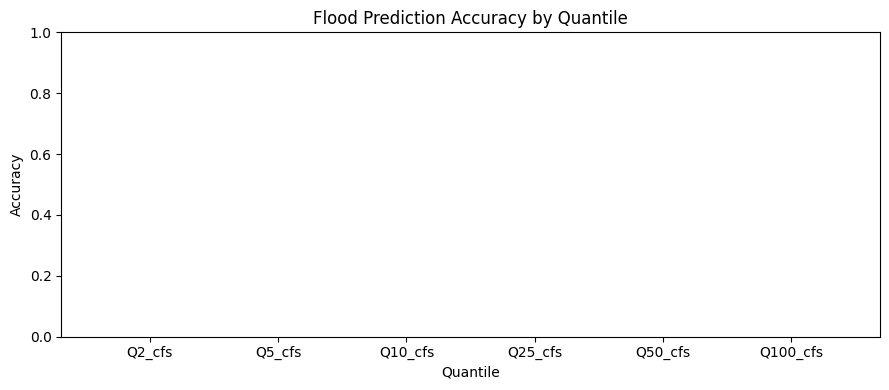


Site 06799100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              201.2 CFS       -489.5 CFS    717.7 CFS


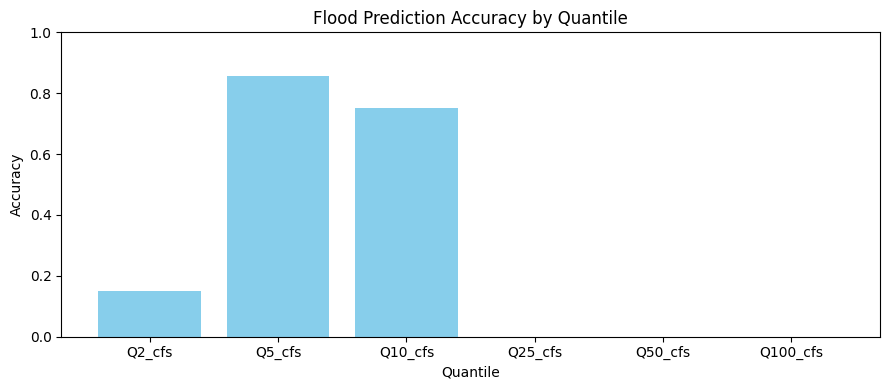


Site 06799315:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1190.1 CFS        763.4 CFS    752.3 CFS


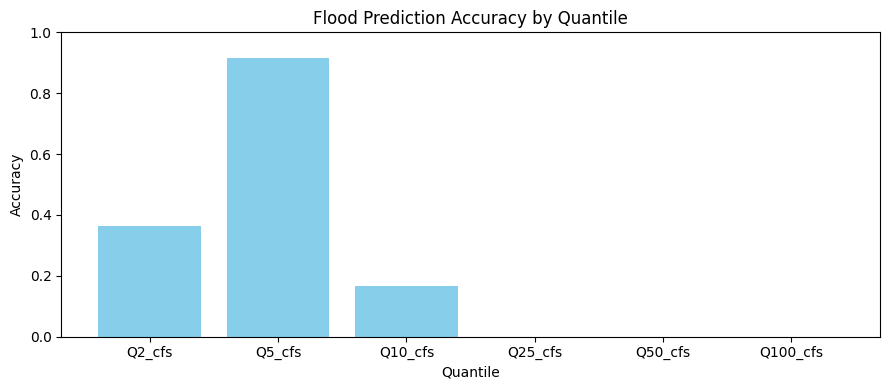


Site 06803495:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              250.8 CFS       -474.1 CFS    738.0 CFS


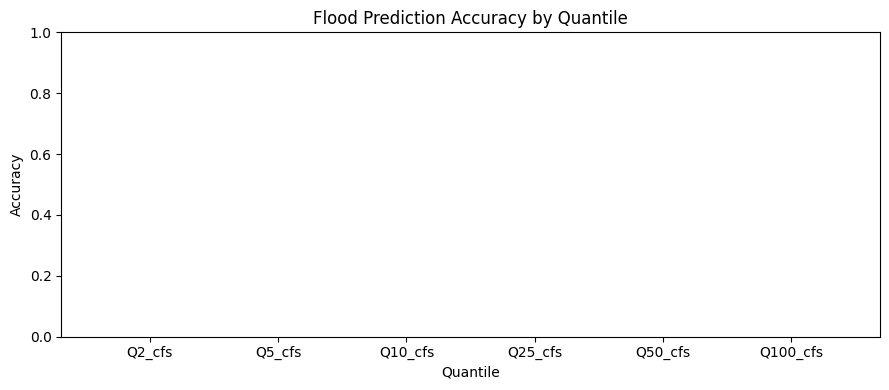


Site 06803500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              272.5 CFS       -462.6 CFS    753.8 CFS


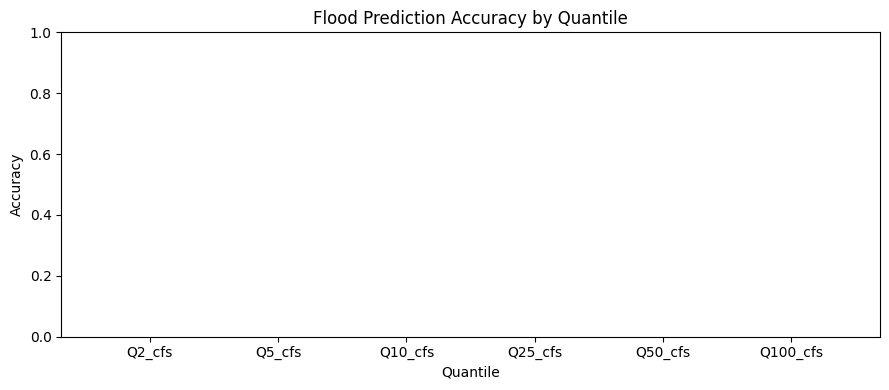


Site 06820500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1379.4 CFS       1791.1 CFS   1893.2 CFS


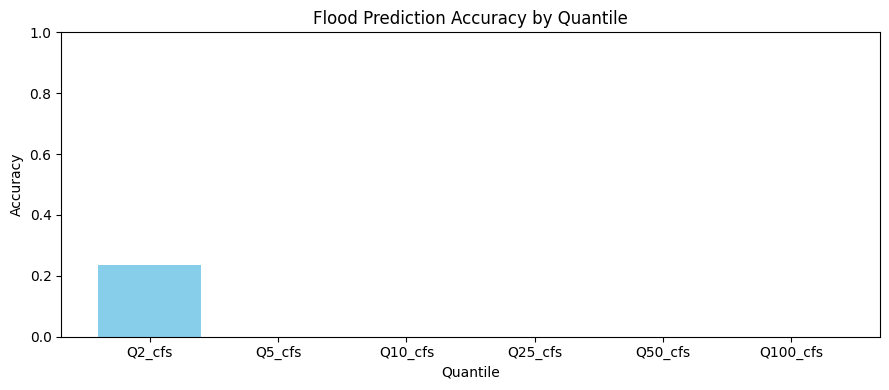


Site 06821500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                2.4 CFS       -661.4 CFS    663.8 CFS


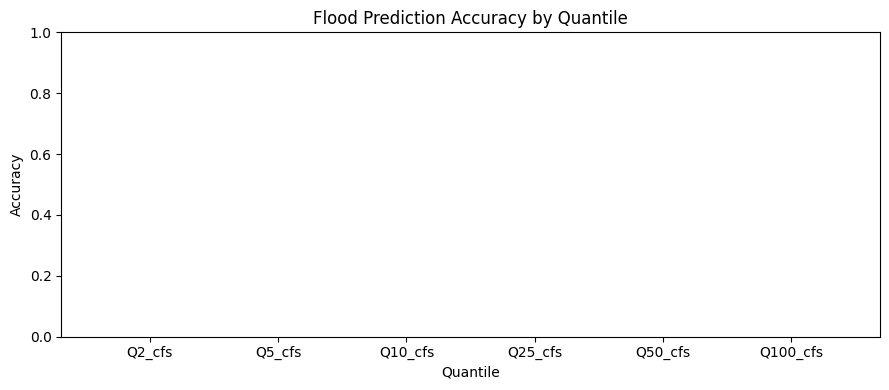


Site 06834000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.6 CFS       -680.1 CFS    700.6 CFS


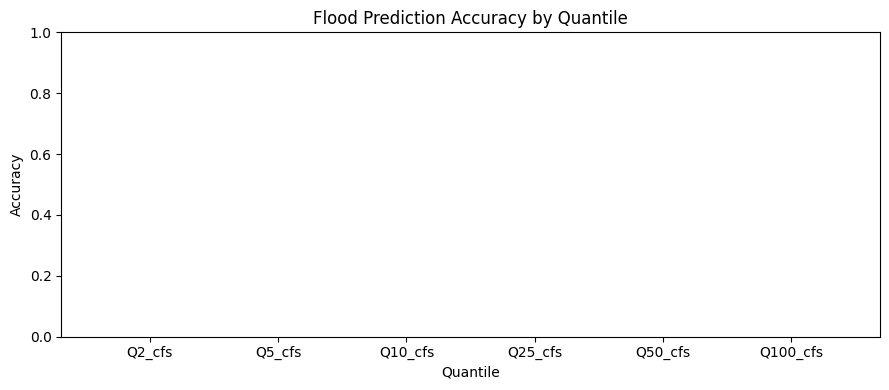


Site 06838000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               12.7 CFS       -665.9 CFS    678.6 CFS


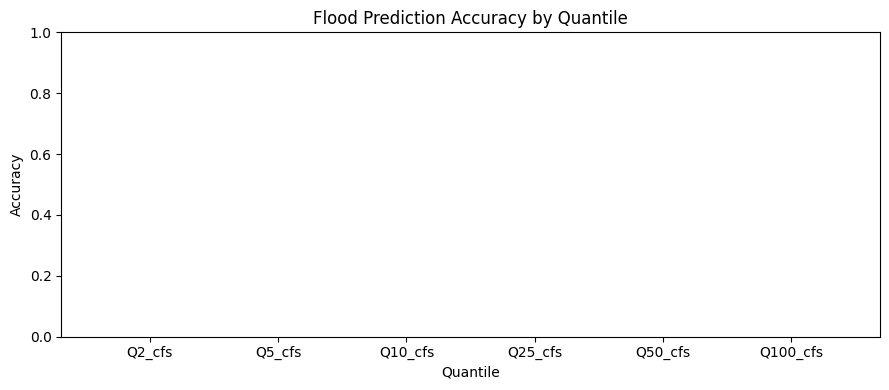


Site 06869950:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               38.8 CFS       -713.8 CFS    752.6 CFS


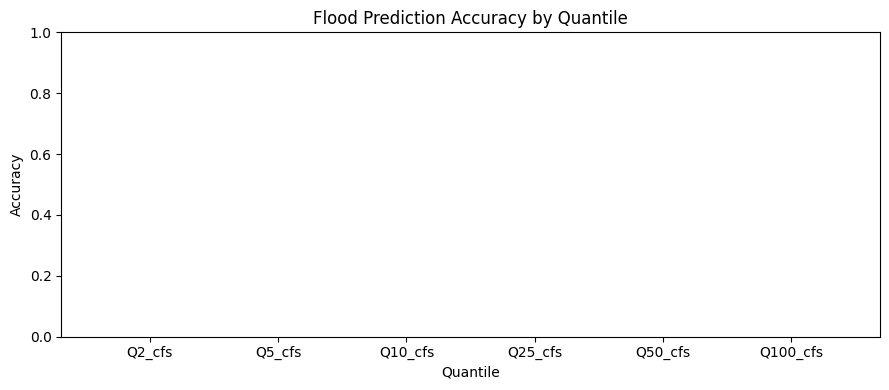


Site 06881000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              447.5 CFS       -249.5 CFS    855.4 CFS


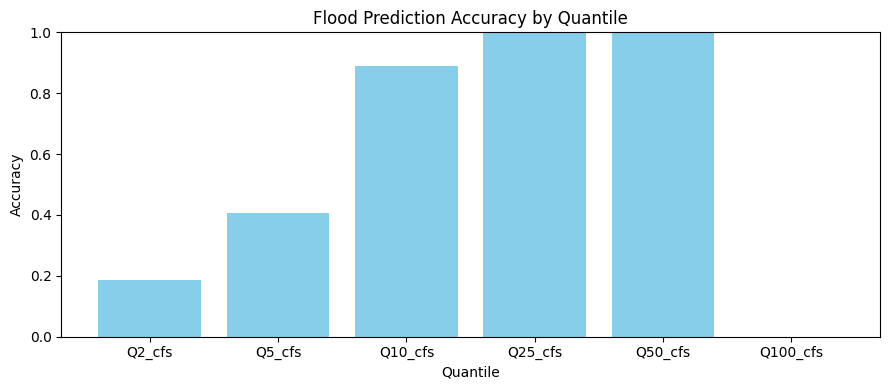


Site 06895000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              158.6 CFS       -639.8 CFS    798.5 CFS


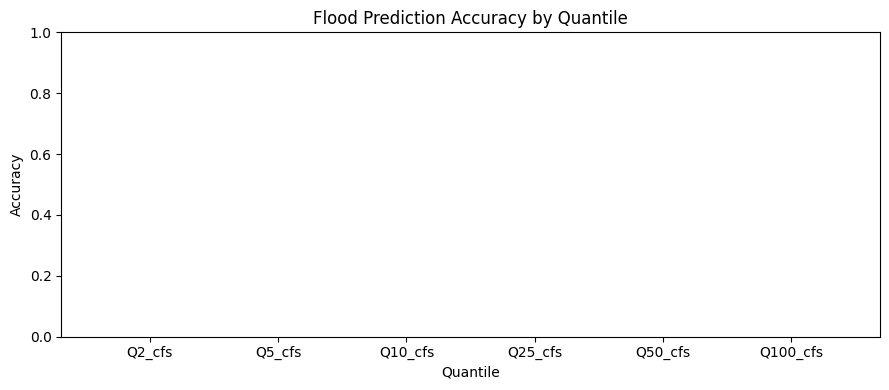


Site 06909500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               86.4 CFS       -675.1 CFS    761.5 CFS


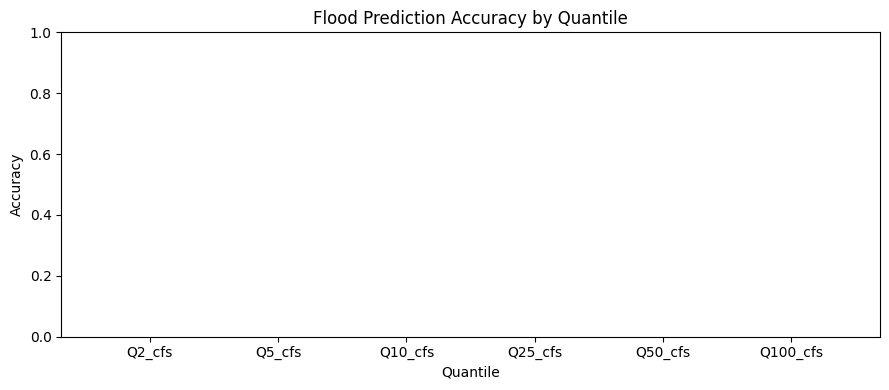


Site 06917000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              308.6 CFS       -474.2 CFS    861.2 CFS


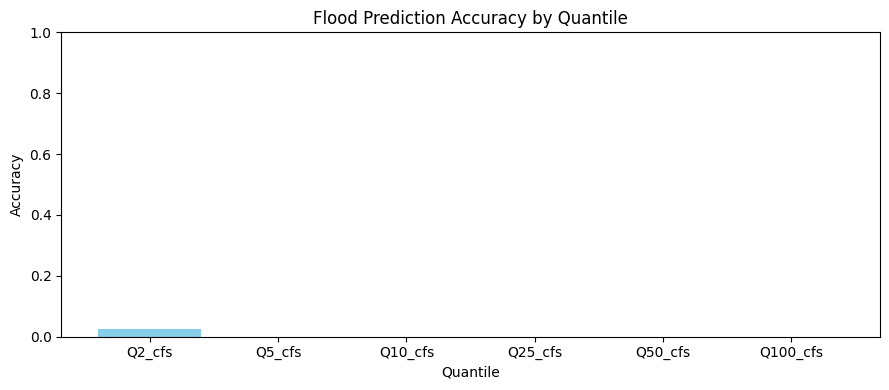


Site 06917060:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              481.3 CFS       -199.6 CFS    906.3 CFS


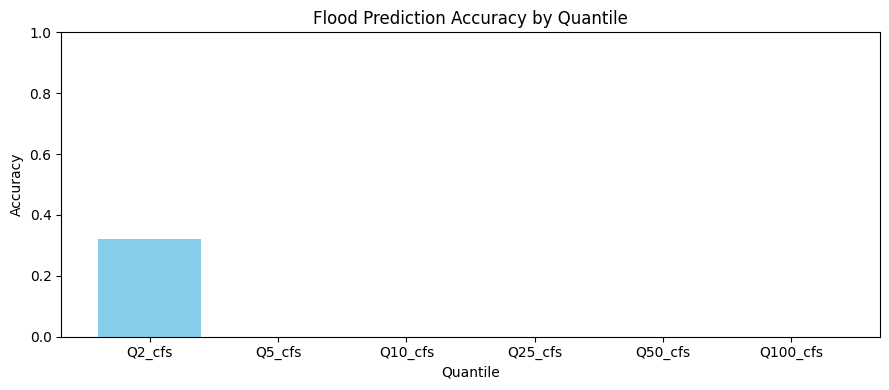


Site 06921590:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              297.0 CFS       -472.8 CFS    825.7 CFS


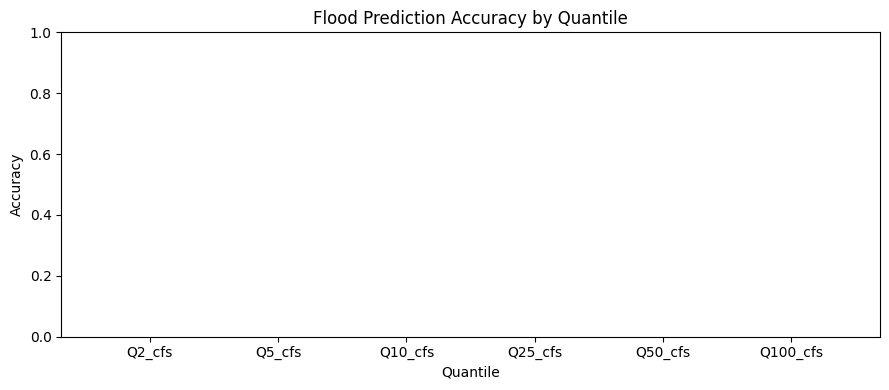


Site 06935755:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                4.1 CFS       -735.8 CFS    739.9 CFS


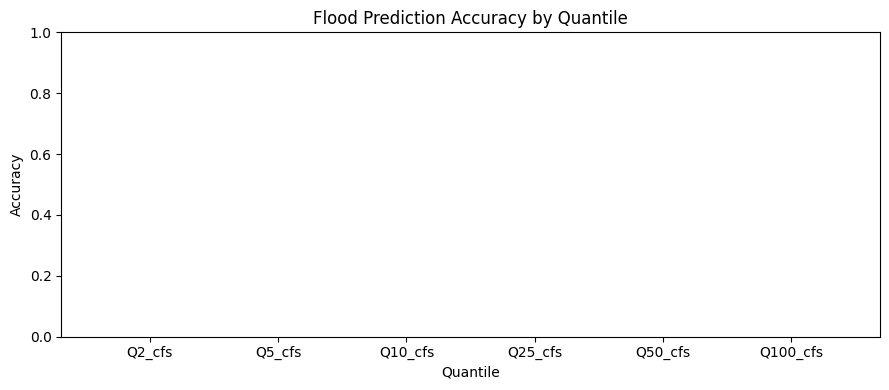


Site 06935955:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.5 CFS       -714.7 CFS    735.1 CFS


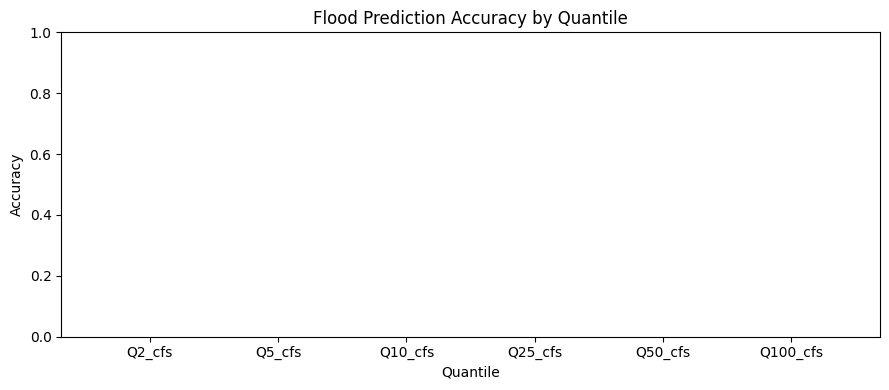

In [7]:
pp.evaluate()

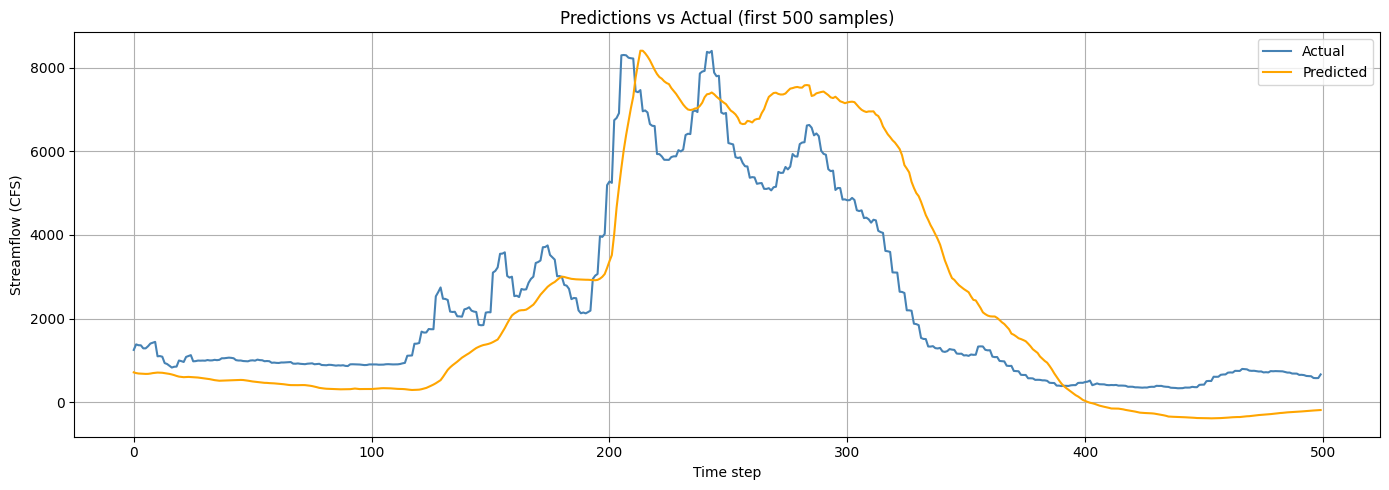

In [8]:
pp.plot_results()

In [9]:
pp.persistence_baseline()

Model                   MAE (scaled)   RMSE (scaled)        NSE
--------------------------------------------------------------
Persistence                   0.0968          0.5559     0.6955
Model                         0.6727          0.9679     0.0769


Subsampling X_test from 338699 to 300 samples for SHAP...
Computing SHAP values via KernelSHAP (nsamples=200)...


 14%|█▍        | 42/300 [02:18<14:26,  3.36s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\shap\explainers\_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
 70%|██████▉   | 209/300 [11:35<04:59,  3.30s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.445e-01, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
 

Done.


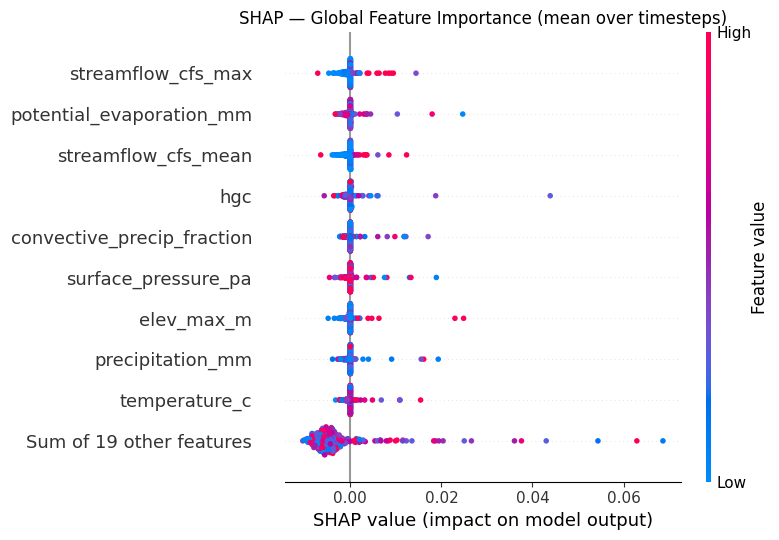

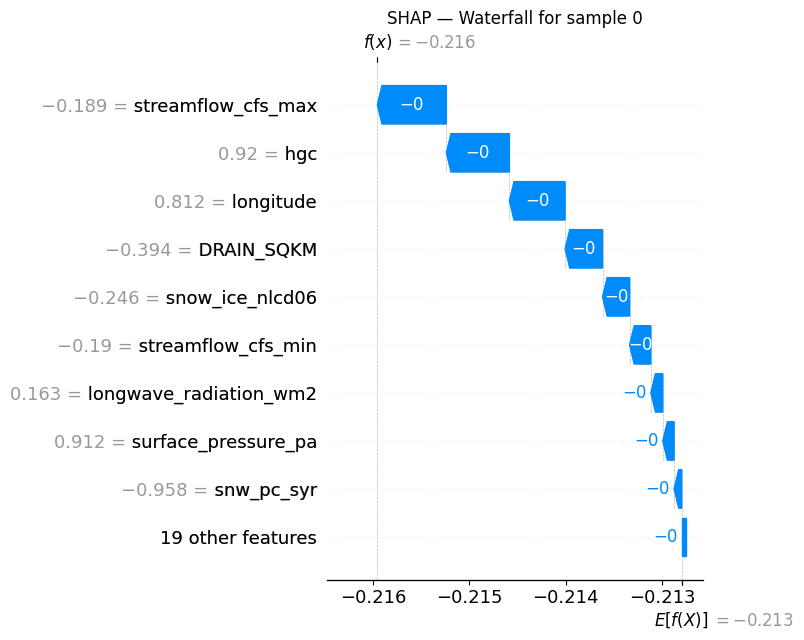

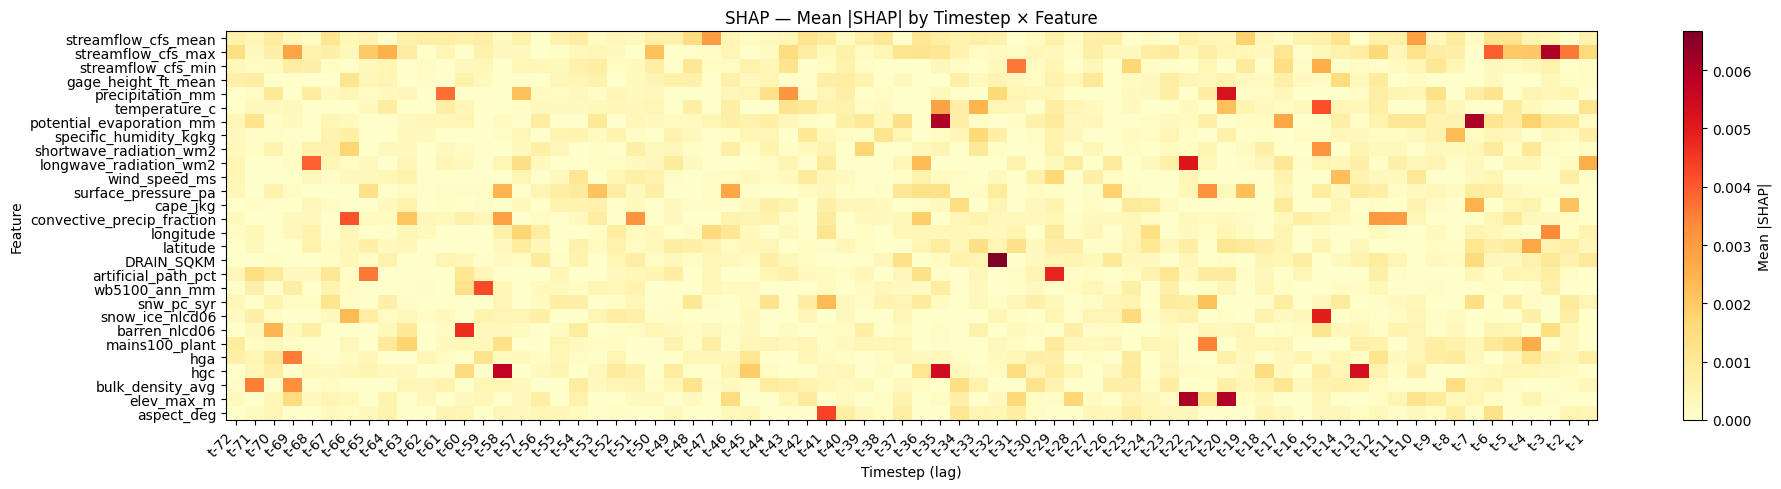

In [10]:
pp.compute_shap()